In [1]:
from pathlib import Path
from dbnomics import fetch_series
import pandas as pd

ROOT = Path(".").resolve()
raw_path = ROOT / "raw" / "ice_ttf_dbnomics.parquet"

if raw_path.exists():
    raw = pd.read_parquet(raw_path)
    print("loaded cache", raw_path, raw.shape)
else:
    raw = fetch_series("ICE", "DUTCH_TTF_GAS_FUTURES", max_nb_series=500)
    raw.to_parquet(raw_path)
    print("saved", raw_path, raw.shape)

raw.head()

saved /Users/verena/Documents/Python_Projects/ttf_dbnomics/raw/ice_ttf_dbnomics.parquet (218145, 14)


,@frequency,provider_code,dataset_code,dataset_name,series_code,series_name,original_period,period,original_value,value,FREQ,CONTRACT,Frequency,Contract
0,daily,ICE,DUTCH_TTF_GAS_FUTURES,Dutch TTF Gas Futures,D.5460494,Daily – Dec22,2020-11-11,2020-11-11,15.769,15.769,D,5460494,Daily,Dec22
1,daily,ICE,DUTCH_TTF_GAS_FUTURES,Dutch TTF Gas Futures,D.5460494,Daily – Dec22,2020-11-12,2020-11-12,15.505,15.505,D,5460494,Daily,Dec22
2,daily,ICE,DUTCH_TTF_GAS_FUTURES,Dutch TTF Gas Futures,D.5460494,Daily – Dec22,2020-11-13,2020-11-13,15.515,15.515,D,5460494,Daily,Dec22
3,daily,ICE,DUTCH_TTF_GAS_FUTURES,Dutch TTF Gas Futures,D.5460494,Daily – Dec22,2020-11-16,2020-11-16,15.594,15.594,D,5460494,Daily,Dec22
4,daily,ICE,DUTCH_TTF_GAS_FUTURES,Dutch TTF Gas Futures,D.5460494,Daily – Dec22,2020-11-17,2020-11-17,15.404,15.404,D,5460494,Daily,Dec22


In [3]:
print(raw.columns.tolist())
print("rows", len(raw), "series", raw["series_code"].nunique())
print(raw["series_name"].drop_duplicates().head(30).tolist())
print(raw["period"].min(), "→", raw["period"].max())

['@frequency', 'provider_code', 'dataset_code', 'dataset_name', 'series_code', 'series_name', 'original_period', 'period', 'original_value', 'value', 'FREQ', 'CONTRACT', 'Frequency', 'Contract']
rows 218145 series 218
['Daily – Dec22', 'Daily – Jan23', 'Daily – Feb23', 'Daily – Mar23', 'Daily – Apr23', 'Daily – May23', 'Daily – Jun23', 'Daily – Jul23', 'Daily – Aug23', 'Daily – Sep23', 'Daily – Summer23', 'Daily – Oct23', 'Daily – Nov23', 'Daily – Dec23', 'Daily – Cal 23', 'Daily – Jan24', 'Daily – Feb24', 'Daily – Mar24', 'Daily – Winter23', 'Daily – Apr24', 'Daily – May24', 'Daily – Aug24', 'Daily – Dec24', 'Daily – Jul24', 'Daily – Jun24', 'Daily – Nov24', 'Daily – Oct24', 'Daily – Sep24', 'Daily – Cal 24', 'Daily – Jan25']
2020-11-11 00:00:00 → 2026-09-03 00:00:00


In [4]:
import re

MON = {"Jan":1,"Feb":2,"Mar":3,"Apr":4,"May":5,"Jun":6,
       "Jul":7,"Aug":8,"Sep":9,"Oct":10,"Nov":11,"Dec":12}
pat = re.compile(r"(Jan|Feb|Mar|Apr|May|Jun|Jul|Aug|Sep|Oct|Nov|Dec)(\d{2})$")

s = raw.copy()
s["period"] = pd.to_datetime(s["period"])
label = s["series_name"].str.replace(r"^Daily\s+[–-]\s+", "", regex=True).str.strip()
m = label.str.extract(pat)
s["month_num"] = m[0].map(MON)
s["year"] = pd.to_numeric(m[1], errors="coerce") + 2000
s = s.dropna(subset=["month_num", "year", "value"])
s["delivery_month"] = pd.to_datetime(
    {"year": s["year"].astype(int), "month": s["month_num"].astype(int), "day": 1}
)

panel = (
    s.rename(columns={"period": "trade_date", "value": "settle_eur_mwh"})
    [["trade_date", "delivery_month", "settle_eur_mwh"]]
    .drop_duplicates(["trade_date", "delivery_month"])
    .sort_values(["trade_date", "delivery_month"])
    .reset_index(drop=True)
)
panel.to_csv(ROOT / "processed" / "ttf_monthly_panel.csv", index=False)
print(panel.head())
print("n_dates", panel["trade_date"].nunique(),
      "n_months", panel["delivery_month"].nunique(),
      "rows", len(panel))
print("delivery", panel["delivery_month"].min().date(), "→", panel["delivery_month"].max().date())

  trade_date delivery_month  settle_eur_mwh
0 2020-11-11     2022-12-01          15.769
1 2020-11-11     2023-01-01          15.857
2 2020-11-11     2023-02-01          15.969
3 2020-11-11     2023-03-01          15.779
4 2020-11-11     2023-04-01          14.908
n_dates 1502 n_months 133 rows 150657
delivery 2022-12-01 → 2033-12-01


In [5]:
counts = panel.groupby("trade_date")["delivery_month"].nunique()
asof = counts[counts >= 6].index.max()
strip = (
    panel.loc[panel["trade_date"] == asof, ["delivery_month", "settle_eur_mwh"]]
    .sort_values("delivery_month")
    .reset_index(drop=True)
)
print("as-of", asof.date(), "n_months", len(strip))
strip

as-of 2026-09-03 n_months 51


,delivery_month,settle_eur_mwh
0,2026-10-01,71.810
1,2026-11-01,71.557
2,2026-12-01,71.276
3,2027-01-01,70.943
4,2027-02-01,69.882
5,2027-03-01,65.871
6,2027-04-01,53.878
7,2027-05-01,48.823
8,2027-06-01,47.428
9,2027-07-01,47.017


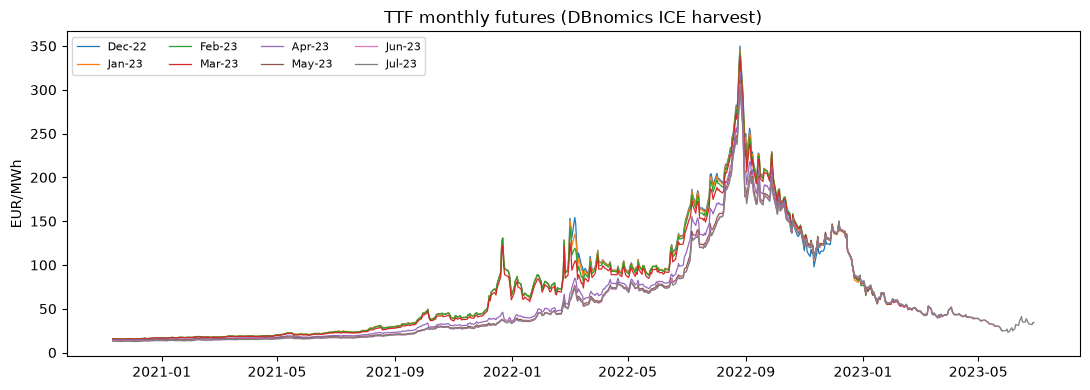

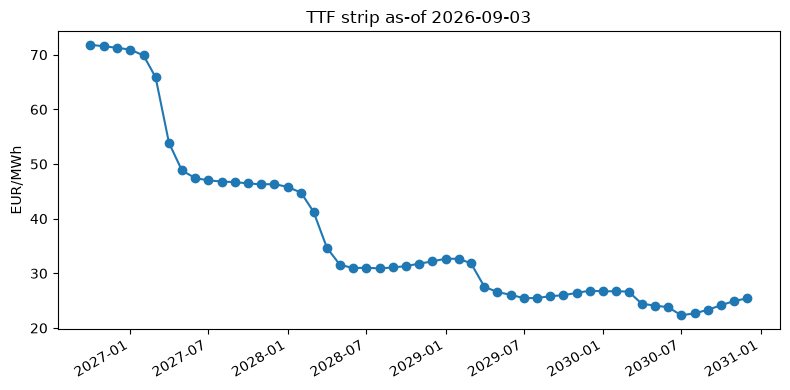

In [6]:
import matplotlib.pyplot as plt

wide = panel.pivot_table(
    index="trade_date", columns="delivery_month", values="settle_eur_mwh"
)

fig, ax = plt.subplots(figsize=(11, 4))
for col in list(wide.columns)[:8]:
    ax.plot(wide.index, wide[col], lw=0.9, label=col.strftime("%b-%y"))
ax.set_ylabel("EUR/MWh")
ax.set_title("TTF monthly futures (DBnomics ICE harvest)")
ax.legend(ncol=4, fontsize=8)
fig.tight_layout()
fig.savefig(ROOT / "figures" / "ttf_selected_months.png", dpi=120)
plt.show()

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(strip["delivery_month"], strip["settle_eur_mwh"], marker="o")
ax.set_ylabel("EUR/MWh")
ax.set_title(f"TTF strip as-of {asof.date()}")
fig.autofmt_xdate()
fig.tight_layout()
fig.savefig(ROOT / "figures" / "ttf_strip_asof.png", dpi=120)
plt.show()